# 5 — Actuation, PD Control, and Rhythm

The motors were never ideal · SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/05-actuation/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** Not for training —
    MuJoCo renders video through EGL on Colab, and that needs the GPU
    runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

## A lie we have been telling

Last week we commanded joint angles and the robot went there. Mostly.

Look again at the Week 4 data: the pelvis was commanded to 0.72 m and
never quite arrived. Something between “the command” and “the motion” is
not ideal, and this week we open it up.

Three questions:

1.  What *is* a position actuator, mechanically?
2.  Why does the robot sag below its commanded height?
3.  What happens when the motors are not strong enough?

------------------------------------------------------------------------

## The actuator is a controller in disguise

MuJoCo’s “position actuator” is not a servo that magically achieves an
angle. It is a **PD controller** written into the model file:

$$\tau = k_p\,(\text{ctrl} - q) \;-\; k_v\,\dot{q}$$

In [1]:
try:
    import soc4180
except ImportError:
    %pip install -q "soc4180 @ git+https://github.com/gnoejh/soc4180.git"
    import soc4180

import numpy as np
import mujoco

model = soc4180.load_g1()
kp, kv = soc4180.gains(model)

print(f"kp : {np.unique(kp)}            (identical on every joint)")
print(f"kv : {kv.min():.2f} .. {kv.max():.2f}   ({len(np.unique(kv))} distinct values)")

kp : [500.]            (identical on every joint)
kv : 4.55 .. 43.01   (27 distinct values)

**Stiffness is uniform; damping is not.** Heavier joints nearer the
trunk carry more damping, because the same stiffness driving a larger
inertia would ring.

------------------------------------------------------------------------

## One joint is a second-order system

Put the servo law into Newton’s law for one joint with effective inertia
$M$ (the other joints held still):

$$M\ddot{q} + k_v\,\dot{q} + k_p\,q = k_p\,\text{ctrl}
\qquad\qquad
\omega_n = \sqrt{\frac{k_p}{M}},\qquad
\zeta = \frac{k_v}{2\sqrt{k_p M}}$$

$\omega_n$ says how fast the joint responds; $\zeta$ says whether it
overshoots ($\zeta < 1$), creeps ($\zeta > 1$), or arrives as fast as
possible without overshooting ($\zeta = 1$). Read $M$ off the mass
matrix and ask what the G1’s designers chose:

In [2]:
d = soc4180.keyframe_data(model, "stand"); mujoco.mj_forward(model, d)
M = np.zeros((model.nv, model.nv)); mujoco.mj_fullM(model, d, M)
dofs = model.jnt_dofadr[model.actuator_trnid[:, 0]]
zeta = kv / (2 * np.sqrt(kp * M[dofs, dofs]))
for a in (0, 3, 4, 12, 16):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_ACTUATOR, a)
    print(f"  {name:26s} M = {M[dofs[a], dofs[a]]:.4f}   kv = {kv[a]:5.2f}   zeta = {zeta[a]:.2f}")
print(f"\nall twelve leg joints: zeta = {zeta[:12].min():.2f} .. {zeta[:12].max():.2f}")

  left_hip_pitch_joint       M = 0.9250   kv = 43.01   zeta = 1.00
  left_knee_joint            M = 0.1256   kv = 15.85   zeta = 1.00
  left_ankle_pitch_joint     M = 0.0128   kv =  5.06   zeta = 1.00
  waist_yaw_joint            M = 0.2804   kv = 23.29   zeta = 0.98
  left_shoulder_roll_joint   M = 0.1865   kv = 13.49   zeta = 0.70

all twelve leg joints: zeta = 1.00 .. 1.00

**Every leg joint is critically damped, $\zeta = 1.00$.** That is why
$k_v$ varies by a factor of ten while $k_p$ does not: the damping was
set to $2\sqrt{k_p M}$ joint by joint, so the heavy hip and the light
ankle respond the same way. The arms are looser, 0.7 to 1.9.

------------------------------------------------------------------------

## The step response, measured

Gravity off, robot floating, and the left knee is asked to go from 0 to
0.5 rad:

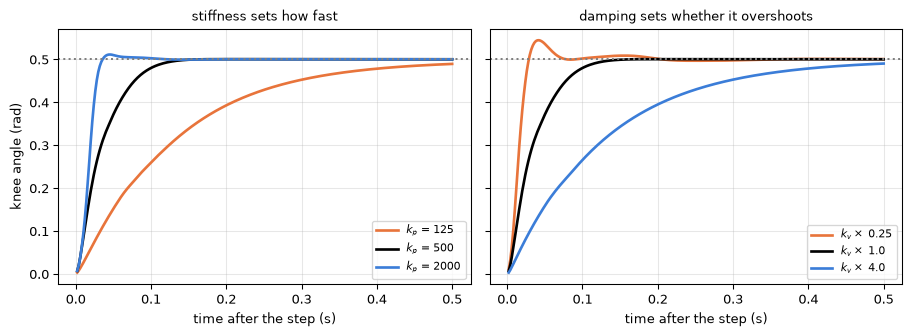

In [3]:
import matplotlib.pyplot as plt

def step_response(kp_scale=1.0, kv_scale=1.0, seconds=0.5):
    m = soc4180.load_g1(); soc4180.scale_gains(m, kp_scale, kv_scale)
    m.opt.gravity[:] = 0
    d = soc4180.keyframe_data(m, "stand")
    qi = m.jnt_qposadr[m.actuator_trnid[3, 0]]          # the left knee
    for _ in range(200):
        mujoco.mj_step(m, d)                              # settle first
    d.ctrl[3] = 0.5
    t0, t, q = d.time, [], []
    while d.time < t0 + seconds:
        mujoco.mj_step(m, d); t.append(d.time - t0); q.append(d.qpos[qi])
    return np.array(t), np.array(q)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.6, 3.6), sharey=True)
for scale, col in ((0.25, "#e8743b"), (1.0, "k"), (4.0, "#3b7dd8")):
    t, q = step_response(kp_scale=scale)
    ax0.plot(t, q, lw=2, color=col, label=f"$k_p$ = {500 * scale:.0f}")
for scale, col in ((0.25, "#e8743b"), (1.0, "k"), (4.0, "#3b7dd8")):
    t, q = step_response(kv_scale=scale)
    ax1.plot(t, q, lw=2, color=col, label=fr"$k_v \times$ {scale}")
for ax, title in ((ax0, "stiffness sets how fast"), (ax1, "damping sets whether it overshoots")):
    ax.axhline(0.5, color="0.5", ls=":"); ax.set_xlabel("time after the step (s)")
    ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=0.3); ax.set_title(title, fontsize=10)
ax0.set_ylabel("knee angle (rad)")
fig.tight_layout(); plt.show()

Four times the stiffness reaches the target three times sooner — and
draws four times the torque, 1000 N·m against 250 for this half-radian
step. A quarter of the damping overshoots by 9%; four times the damping
never quite arrives. The nominal pair does neither, which is what
$\zeta = 1$ means.

------------------------------------------------------------------------

## Verify it, do not believe it

If that equation really is the actuator, we can predict the torque
exactly:

In [4]:
data = soc4180.keyframe_data(model, "stand")
knee = soc4180.leg_qpos_indices(model, "left")[3]
data.qpos[knee] = 0.30          # bend the knee 0.3 rad away from the command
data.qvel[:] = 0                # no velocity, so the kv term vanishes
data.ctrl[:] = 0
mujoco.mj_forward(model, data)

a = 3                            # the left knee actuator
q = data.qpos[model.jnt_qposadr[model.actuator_trnid[a, 0]]]
predicted = kp[a] * (data.ctrl[a] - q)

print(f"predicted torque = {predicted:+.3f} N m")
print(f"actual   torque  = {data.actuator_force[a]:+.3f} N m")

predicted torque = -150.000 N m
actual   torque  = -150.000 N m

A spring, pulling the joint back toward its setpoint with a force
proportional to the error. **That is why the robot sags: a spring at
rest is a spring under load, and load means deflection.**

------------------------------------------------------------------------

## Measure the sag

In [5]:
from soc4180.walking import WalkingController, GaitParams

controller = WalkingController(model, GaitParams(n_steps=8))
data = controller.initial_data()

sag, peak = [], 0.0
while data.time < controller.total_time:
    data.ctrl[:] = controller.control(data.time)
    mujoco.mj_step(model, data)
    peak = max(peak, float(np.abs(data.actuator_force).max()))
    if data.time > controller.params.settle_time:
        sag.append(controller.targets_at(data.time)[0][2] - data.qpos[2])

print(f"commanded pelvis height : {controller.params.pelvis_height:.3f} m")
print(f"mean sag                : {np.mean(sag)*1000:+.1f} mm")
print(f"worst sag               : {np.max(sag)*1000:+.1f} mm")
print(f"peak joint torque       : {peak:.1f} N m")

commanded pelvis height : 0.720 m
mean sag                : +11.0 mm
worst sag               : +27.1 mm
peak joint torque       : 123.7 N m

Eleven millimetres of steady droop. Not a bug — the necessary deflection
of a finite spring holding up a 33 kg robot.

------------------------------------------------------------------------

## Sag against stiffness

A spring under a fixed load deflects as $1/k_p$. Sweep the stiffness and
check:

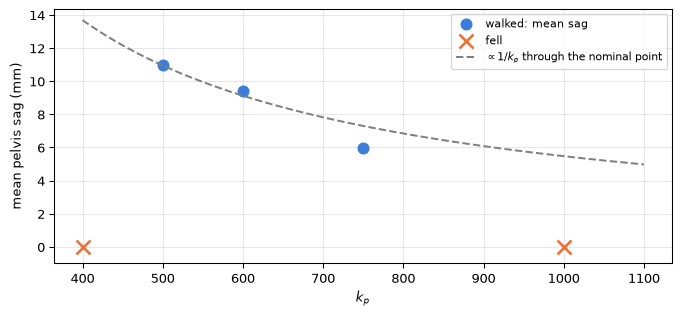

In [6]:
def walk_sag(kp_scale):
    m = soc4180.load_g1(); soc4180.scale_gains(m, kp_scale, 1.0)
    c = WalkingController(m, GaitParams(n_steps=8)); d = c.initial_data(); s = []
    while d.time < c.total_time:
        d.ctrl[:] = c.control(d.time); mujoco.mj_step(m, d)
        if d.time > c.params.settle_time:
            s.append(c.targets_at(d.time)[0][2] - d.qpos[2])
    return np.mean(s) * 1000, d.qpos[2]

scales = np.array([0.8, 1.0, 1.2, 1.5, 2.0])
sags, ok = [], []
for s in scales:
    mm, z = walk_sag(s); sags.append(mm); ok.append(z > 0.5)
sags, ok = np.array(sags), np.array(ok)
fig, ax = plt.subplots(figsize=(7.2, 3.4))
ax.plot(500 * scales[ok], sags[ok], "o", ms=8, color="#3b7dd8", label="walked: mean sag")
ax.plot(500 * scales[~ok], np.zeros((~ok).sum()), "x", ms=10, mew=2, color="#e8743b", label="fell")
kk = np.linspace(400, 1100, 100)
ax.plot(kk, sags[1] * 500 / kk, "--", color="0.5", label=r"$\propto 1/k_p$ through the nominal point")
ax.set_xlabel("$k_p$"); ax.set_ylabel("mean pelvis sag (mm)"); ax.set_ylim(bottom=-1)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

Between 500 and 750 the sag follows the spring law. Below 500 the robot
does not sag more — it **falls**: a leg that gives too much at support
exchange has stopped supporting. Above 750 it falls too, for the reason
on the next slides — the gait’s timing was tuned against one particular
stiffness.

------------------------------------------------------------------------

## The motors in this model are infinitely strong

Before tuning anything, check what the simulator is actually giving us:

In [7]:
print(f"torque limit in the model : {soc4180.torque_limit(model)}")
print(f"control limits set?       : {bool(np.any(model.actuator_ctrllimited))}")

torque limit in the model : None
control limits set?       : True

**`None`.** The MJCF constrains the *commanded angle* to the joint
range, but places no bound whatsoever on the torque used to get there.
Our walker happily drew 124 N·m peaks and nothing objected.

No real motor behaves like this. Every hardware actuator has a stall
torque, a thermal limit, and a gearbox that fails. **This is a
sim-to-real gap sitting in plain sight in the model file**, and unlike
most of them it costs one line to close.

------------------------------------------------------------------------

## Close it and find the breaking point

In [8]:
def walks(torque_limit=None, kp_scale=1.0, kv_scale=1.0, n_steps=8):
    m = soc4180.load_g1()
    soc4180.scale_gains(m, kp_scale, kv_scale)
    soc4180.set_torque_limit(m, torque_limit)
    c = WalkingController(m, GaitParams(n_steps=n_steps))
    d = c.initial_data()
    while d.time < c.total_time:
        d.ctrl[:] = c.control(d.time)
        mujoco.mj_step(m, d)
    return float(d.qpos[0]), float(d.qpos[2])

for limit in (30, 45, 50, 55, 80, None):
    x, z = walks(torque_limit=limit)
    tag = "no limit" if limit is None else f"{limit:3d} N m"
    print(f"  {tag:9s} -> travelled {x:+.3f} m, pelvis {z:.3f} m   "
          f"{'FELL' if z < 0.5 else 'walked'}")

   30 N m   -> travelled -0.405 m, pelvis 0.061 m   FELL
   45 N m   -> travelled -0.440 m, pelvis 0.061 m   FELL
   50 N m   -> travelled -0.500 m, pelvis 0.061 m   FELL
   55 N m   -> travelled +0.650 m, pelvis 0.718 m   walked
   80 N m   -> travelled +0.660 m, pelvis 0.716 m   walked
  no limit  -> travelled +0.659 m, pelvis 0.716 m   walked

A crisp threshold: the gait **needs more than 50 N·m** and survives at
55. Below that the stance leg cannot hold the robot up during weight
transfer, and it goes down.

------------------------------------------------------------------------

## Where the torque goes

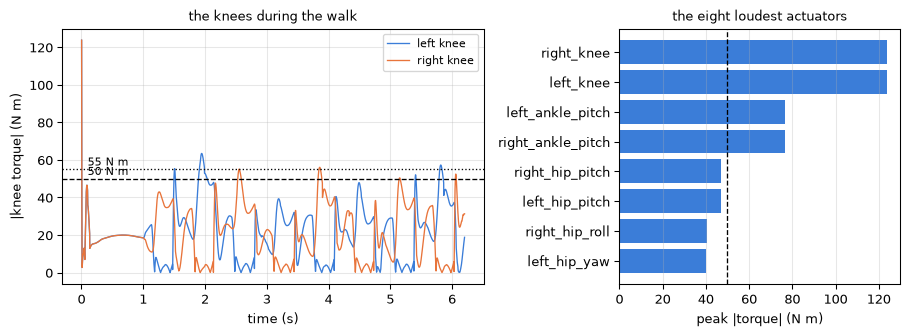

left knee above 50 N m for 4.0% of the walk

In [9]:
m = soc4180.load_g1()
c = WalkingController(m, GaitParams(n_steps=8)); d = c.initial_data()
tt, tau = [], []
while d.time < c.total_time:
    d.ctrl[:] = c.control(d.time); mujoco.mj_step(m, d)
    tt.append(d.time); tau.append(d.actuator_force.copy())
tt, tau = np.array(tt), np.abs(np.array(tau))
names = [mujoco.mj_id2name(m, mujoco.mjtObj.mjOBJ_ACTUATOR, i).replace("_joint", "")
         for i in range(m.nu)]
peak_tau = tau.max(axis=0)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.6, 3.6), gridspec_kw={"width_ratios": [1.5, 1]})
ax0.plot(tt, tau[:, 3], lw=1, color="#3b7dd8", label="left knee")
ax0.plot(tt, tau[:, 9], lw=1, color="#e8743b", label="right knee")
for lim, ls in ((50, "--"), (55, ":")):
    ax0.axhline(lim, color="k", ls=ls, lw=1); ax0.text(0.1, lim + 2, f"{lim} N m", fontsize=8)
ax0.set_xlabel("time (s)"); ax0.set_ylabel("|knee torque| (N m)")
ax0.legend(fontsize=8, loc="upper right"); ax0.grid(alpha=0.3)
ax0.set_title("the knees during the walk", fontsize=10)
order = np.argsort(peak_tau)[::-1][:8]
ax1.barh([names[i] for i in order], peak_tau[order], color="#3b7dd8"); ax1.invert_yaxis()
ax1.axvline(50, color="k", ls="--", lw=1); ax1.set_xlabel("peak |torque| (N m)"); ax1.grid(axis="x", alpha=0.3)
ax1.set_title("the eight loudest actuators", fontsize=10)
fig.tight_layout(); plt.show()
print(f"left knee above 50 N m for {(tau[:, 3] > 50).mean():.1%} of the walk")

The knee holds the body up in single support and spikes at every support
exchange. It exceeds 50 N·m for about **4% of the walk** — and that is
enough. A limit that bites for a few hundredths of a second at the wrong
moment is a limit that drops the robot.

------------------------------------------------------------------------

## Tuning the gains

$k_p$ too low and the robot sinks. Too high and it fights itself. Find
the window:

In [10]:
for scale in (0.25, 0.5, 1.0, 2.0, 4.0):
    x, z = walks(kp_scale=scale)
    print(f"  kp = {500*scale:6.0f} -> travelled {x:+.3f} m, pelvis {z:.3f} m   "
          f"{'FELL' if z < 0.5 else 'walked'}")

  kp =    125 -> travelled -0.781 m, pelvis 0.061 m   FELL
  kp =    250 -> travelled -0.729 m, pelvis 0.061 m   FELL
  kp =    500 -> travelled +0.659 m, pelvis 0.716 m   walked
  kp =   1000 -> travelled -0.543 m, pelvis 0.134 m   FELL
  kp =   2000 -> travelled +0.634 m, pelvis 0.134 m   FELL

**Only the nominal gain walks.** Halve it and the legs collapse under
the robot’s weight; double it and the servos overpower the gait’s timing
and throw it over.

------------------------------------------------------------------------

## The textbook fix that does not work

Control theory says stiffness and damping should scale together — hold
the damping ratio $\zeta = k_v / (2\sqrt{k_p\,m})$ constant by scaling
$k_v$ with $\sqrt{k_p}$. Try it:

In [11]:
for scale in (0.25, 0.5, 1.0, 2.0, 4.0):
    x, z = walks(kp_scale=scale, kv_scale=np.sqrt(scale))
    print(f"  kp = {500*scale:6.0f}, kv x{np.sqrt(scale):.2f} -> "
          f"pelvis {z:.3f} m   {'FELL' if z < 0.5 else 'walked'}")

  kp =    125, kv x0.50 -> pelvis 0.061 m   FELL
  kp =    250, kv x0.71 -> pelvis 0.061 m   FELL
  kp =    500, kv x1.00 -> pelvis 0.716 m   walked
  kp =   1000, kv x1.41 -> pelvis 0.068 m   FELL
  kp =   2000, kv x2.00 -> pelvis 0.136 m   FELL

**Still only the nominal gain survives.** The theory is not wrong — it
is about a single joint tracking a setpoint. Our failure is not one
joint ringing; it is a *whole-body gait whose timing was tuned against
this particular plant*. Change the plant and the trajectory no longer
fits it.

Remember that when a learned policy shrugs this off in Week 11.

------------------------------------------------------------------------

## Rhythm without a model

The Week 4 walker needed a balance model. Biology often seems not to: a
**central pattern generator** in the spinal cord produces rhythmic
stepping with no plan at all. Two anti-phase oscillators, driving hips
and knees:

In [12]:
cpg = soc4180.CPG(model, frequency=1.2, hip_amplitude=0.25, knee_amplitude=0.40)
data = cpg.initial_data()
frames = soc4180.render_rollout(
    model, data, duration=8.0, fps=30, width=560, height=440,
    ctrl_fn=cpg.ctrl_fn(), track="pelvis", distance=2.6, azimuth=135,
)
print(f"after 8 s: x={data.qpos[0]:+.3f} m, pelvis {data.qpos[2]:.3f} m")
soc4180.show_video(frames, fps=30)

after 8 s: x=+0.150 m, pelvis 0.129 m

------------------------------------------------------------------------

## What the oscillator commands

Two sinusoids per leg, in anti-phase between the legs; the knee only
ever bends (a half-wave rectified sine) and the ankle counter-rotates to
keep the foot roughly level:

$$\theta_{\text{hip}} = A_h \sin\phi,\qquad
\theta_{\text{knee}} = A_k \max(0, \sin\phi),\qquad
\theta_{\text{ankle}} = -\tfrac{1}{2} A_h \sin\phi,\qquad
\phi = 2\pi f t \;(+\pi\ \text{for the other leg})$$

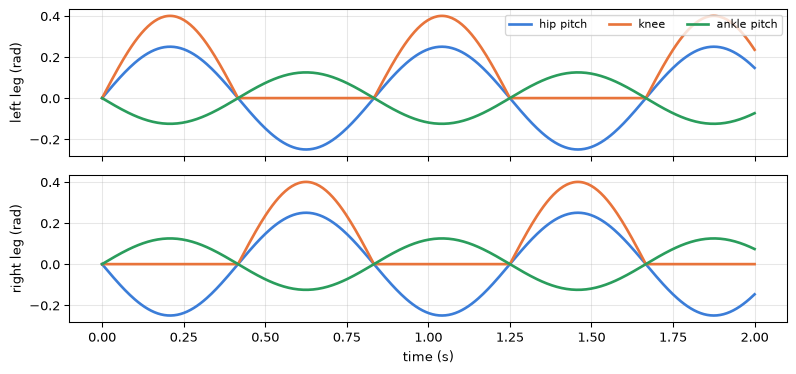

In [13]:
from soc4180 import kinematics as kin
tt = np.linspace(0, 2.0, 400)
idx = {s: kin.leg_qpos_indices(model, s) for s in ("left", "right")}
act_q = np.array([model.jnt_qposadr[model.actuator_trnid[a, 0]] for a in range(model.nu)])
cmd = np.array([cpg.control(cpg.settle_time + t) for t in tt])       # actuator order
full = np.tile(cpg.nominal, (len(tt), 1)); full[:, act_q] = cmd
fig, axs = plt.subplots(2, 1, figsize=(8.4, 4.0), sharex=True)
for ax, side in zip(axs, ("left", "right")):
    i = idx[side]
    for j, lab, col in ((0, "hip pitch", "#3b7dd8"), (3, "knee", "#e8743b"), (4, "ankle pitch", "#2a9d5c")):
        ax.plot(tt, full[:, i[j]] - cpg.nominal[i[j]], lw=2, color=col, label=lab)
    ax.set_ylabel(f"{side} leg (rad)"); ax.grid(alpha=0.3)
axs[0].legend(fontsize=8, ncol=3, loc="upper right"); axs[1].set_xlabel("time (s)")
fig.tight_layout(); plt.show()

A perfectly plausible stepping pattern. It also has no idea where the
floor is.

------------------------------------------------------------------------

## Rhythm is not balance

It falls. So does every parameter setting we tried:

| frequency | hip         | knee        | outcome       |
|-----------|-------------|-------------|---------------|
| 0.8 Hz    | 0.15 – 0.35 | 0.25 – 0.55 | fell (3 of 3) |
| 1.2 Hz    | 0.15 – 0.35 | 0.25 – 0.55 | fell (3 of 3) |
| 1.6 Hz    | 0.15 – 0.35 | 0.25 – 0.55 | fell (3 of 3) |

The legs move in a perfectly good walking pattern. Nothing keeps the
centre of mass over the support polygon, so the robot walks its legs and
falls anyway.

**This is the value of Week 4 stated negatively.** The LIPM was not
decoration; it was the entire reason the robot stayed up.

------------------------------------------------------------------------

## What biology actually does

Real CPGs are not open loop. In an animal the rhythm is continuously
**entrained by sensory feedback** — load on the leg, joint angle, skin
contact — through reflex pathways that adjust the pattern step by step.

An open-loop oscillator is a CPG with its spinal cord cut off from its
body.

That is precisely what we are missing, and it names the next two weeks:

- **Week 6** — read the sensors: what can the robot actually know about
  itself?
- **Weeks 8+** — let a policy learn the feedback rule instead of
  deriving it

------------------------------------------------------------------------

## Where this leaves us

|                       | LIPM walker (W4) | CPG (today) |
|-----------------------|------------------|-------------|
| Model of balance      | yes              | none        |
| Walks                 | yes, ~1 m        | no          |
| Sensors used          | none             | none        |
| Survives gain changes | no               | no          |
| Lines of code         | ~200             | ~20         |

Both are **open loop**. Neither reads a single sensor. One works because
a human did the balance reasoning in advance; the other does not work at
all.

Every remaining week of the course is about closing that loop.

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/05-actuation/lab_servo.py
```

The walker live, with a sphere on every leg joint that turns from green
to red as its torque approaches the reference — the torque limit when
one is set. `SERVOS` at the top of the file lists (stiffness, damping,
limit) settings; keys `1`–`6` select one and restart.

`torque_from_pd(kp, kv, ctrl, q, qdot)` is the actuator law, and it is
empty. Once written, `ENTER` reports how far it is from MuJoCo’s
`actuator_force` (right: ~1e-12). Then **`H` hands the servos over**:
the model’s gains are zeroed and the student’s torques go straight into
`qfrc_applied` — at **1 kHz**, because an explicit spring this stiff is
unstable at 500 Hz (week 1, exercise 14; the engine integrates its own
servo implicitly). A correct law changes nothing; a wrong or empty one
gives the week 0 rag doll.

| Step | Do | Right looks like |
|------------------------|------------------------|------------------------|
| 1 | write the law | gap ~1e-12 on `ENTER` |
| 2 | `H`, then delete the damping term and `R` `H` | identical walk, then ringing |
| 3 | `2` (50 N·m) then `3` (55 N·m) | knees go red at support exchange; one falls, one walks |
| 4 | `4` and `5` (half and double $k_p$) | one sinks, one is thrown; the student says which and why |
| 5 | `SERVO_HZ = 500`, `H` | it blows up; explained with week 1 |
| 6 | the lowest $k_p$ that walks eight steps, in `SERVOS` | `ENTER` prints its sag; sag against $k_p$ on paper |

------------------------------------------------------------------------

## Exercises

1.  **Bisect the torque limit.** Narrow the walking threshold between 50
    and 55 N·m to 1 N·m. Which joint saturates first, and during which
    gait phase?
2.  **Sag versus stiffness.** Plot mean sag against $k_p$ over the range
    that does not fall. Is the relationship $1/k_p$ as a linear spring
    predicts?
3.  **Compensate it.** The sag is ~11 mm and roughly constant. Raise the
    commanded pelvis height by that amount and re-measure. Does the
    tracking error vanish, and does anything else get worse?
4.  **Damping alone.** Hold $k_p$ fixed and sweep $k_v$ over 0.25×–4×.
    Which failure looks like ringing and which like sluggishness?
5.  **Give the CPG a reflex.** Increase knee amplitude on whichever leg
    carries more load (read `data.actuator_force`). Does one feedback
    term save it?
6.  **Cost of transport.** Compute $\int |\tau \dot q|\,dt$ per metre
    for the Week 4 walker. Keep the number — you will compare a learned
    policy against it.

------------------------------------------------------------------------

## Next week

**06 — sensing and state estimation.** The robot has two IMUs and has
not used them once. We read gyroscopes and accelerometers, estimate
torso orientation from noisy signals, and build the observation vector a
learned policy will eventually consume.